In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

/var/folders/yr/h1wgp2sx7mxd3yvwstk5t7k40000gn/T/ipykernel_11526/3753238228.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  low_demand_c1 = df[~high_mask_c1].groupby(pd.qcut(df[~high_mask_c1]['price_item'], NUM_BINS, duplicates='drop'))['item_bought'].mean()
/var/folders/yr/h1wgp2sx7mxd3yvwstk5t7k40000gn/T/ipykernel_11526/3753238228.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_demand_c1 = df[high_mask_c1].groupby(pd.qcut(df[high_mask_c1]['price_item'], NUM_BINS, duplicates='drop'))['item_bought'].mean()
/var/folders/yr/h1wgp2sx7mxd3yvwstk5t7k40000gn/T/ipykernel_11526/3753238228.py:34: Future

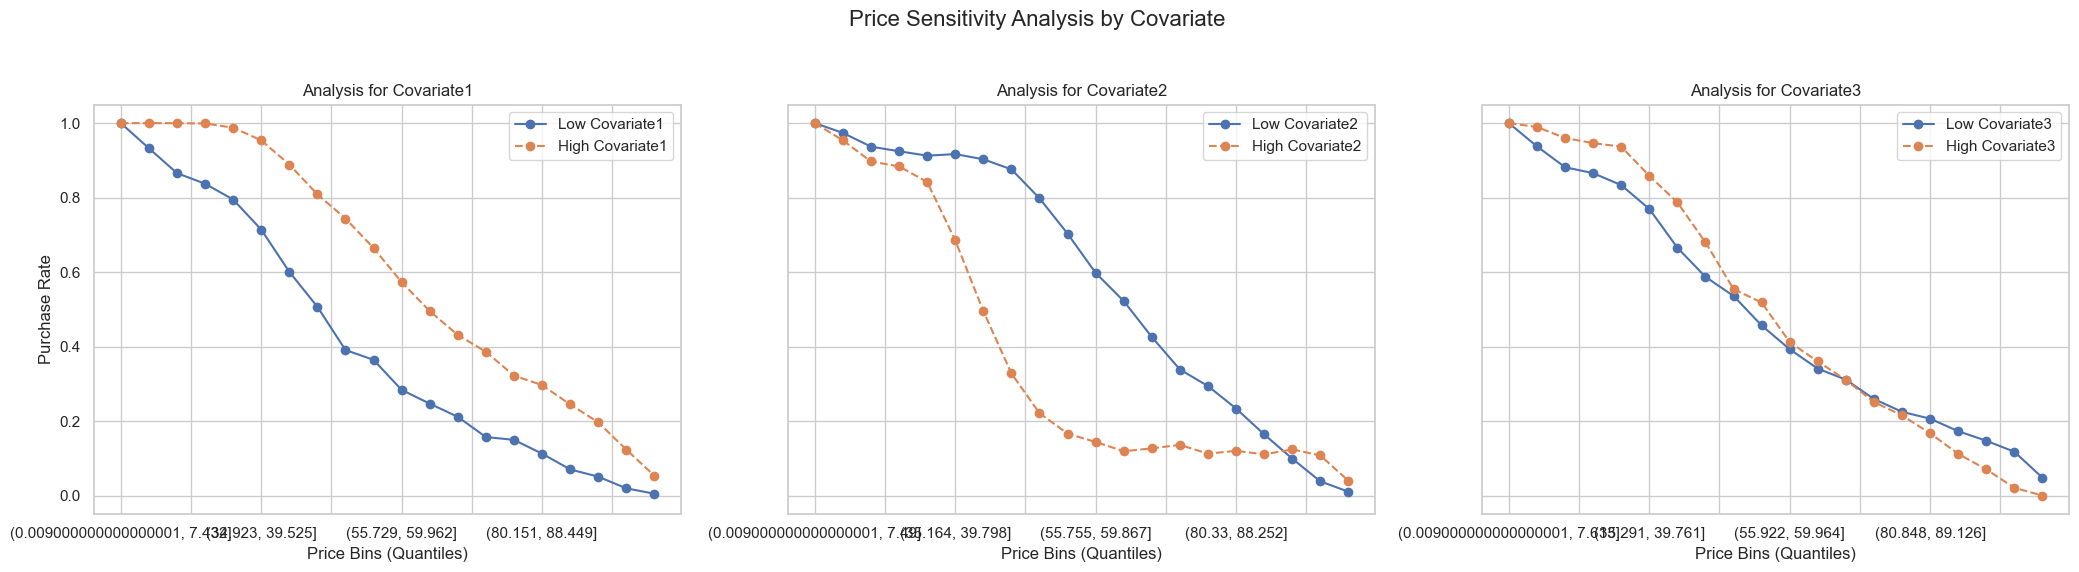

In [3]:
# Set seaborn style for better plots
sns.set_theme(style="whitegrid")

# Define the correct relative path to the data
DATA_PATH = '../../data/train_prices_decisions_2025.csv'


df = pd.read_csv(DATA_PATH)

NUM_BINS = 20

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
fig.suptitle('Price Sensitivity Analysis by Covariate', fontsize=16)

# Cov1
cov1_mean = df['Covariate1'].mean()
high_mask_c1 = (df['Covariate1'] > cov1_mean)
    
low_demand_c1 = df[~high_mask_c1].groupby(pd.qcut(df[~high_mask_c1]['price_item'], NUM_BINS, duplicates='drop'))['item_bought'].mean()
low_demand_c1.plot(ax=axes[0], label='Low Covariate1', marker='o')
    
high_demand_c1 = df[high_mask_c1].groupby(pd.qcut(df[high_mask_c1]['price_item'], NUM_BINS, duplicates='drop'))['item_bought'].mean()
high_demand_c1.plot(ax=axes[0], label='High Covariate1', marker='o', linestyle='--')
    
axes[0].set_title('Analysis for Covariate1')
axes[0].set_ylabel('Purchase Rate')
axes[0].set_xlabel('Price Bins (Quantiles)')
axes[0].legend()

# Cov2
cov2_mean = df['Covariate2'].mean()
high_mask_c2 = (df['Covariate2'] > cov2_mean)
    
low_demand_c2 = df[~high_mask_c2].groupby(pd.qcut(df[~high_mask_c2]['price_item'], NUM_BINS, duplicates='drop'))['item_bought'].mean()
low_demand_c2.plot(ax=axes[1], label='Low Covariate2', marker='o')
    
high_demand_c2 = df[high_mask_c2].groupby(pd.qcut(df[high_mask_c2]['price_item'], NUM_BINS, duplicates='drop'))['item_bought'].mean()
high_demand_c2.plot(ax=axes[1], label='High Covariate2', marker='o', linestyle='--')
    
axes[1].set_title('Analysis for Covariate2')
axes[1].set_xlabel('Price Bins (Quantiles)')
axes[1].legend()

# Cov 3
cov3_median = df['Covariate3'].median()
high_mask_c3 = (df['Covariate3'] > cov3_median)
    
low_demand_c3 = df[~high_mask_c3].groupby(pd.qcut(df[~high_mask_c3]['price_item'], NUM_BINS, duplicates='drop'))['item_bought'].mean()
low_demand_c3.plot(ax=axes[2], label='Low Covariate3', marker='o')

high_demand_c3 = df[high_mask_c3].groupby(pd.qcut(df[high_mask_c3]['price_item'], NUM_BINS, duplicates='drop'))['item_bought'].mean()
high_demand_c3.plot(ax=axes[2], label='High Covariate3', marker='o', linestyle='--')

axes[2].set_title('Analysis for Covariate3')
axes[2].set_xlabel('Price Bins (Quantiles)')
axes[2].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Feature Engineering for Model Optimization
Our basic logistic regression (Model A) is a good start, but our EDA showed complex relationships that a simple linear model can't find. We are engineering new features to "teach" our model these patterns.

### Model B: Price x Covariate 2 Interaction
New Feature: price_x_cov2 = price_item * Covariate2

Our EDA plots showed a large gap between the demand curves for "High" and "Low" Covariate2 customers. This means Covariate2 strongly changes how sensitive a customer is to price. This interaction feature lets our model learn this complex relationship directly.

### Model C: Price x Covariate 1 Interaction
New Feature: price_x_cov1 = price_item * Covariate1

This follows the same logic as Model B. The EDA plots showed a smaller, but still present, gap for Covariate1. We are adding this feature to see if capturing this "smaller influence" adds any predictive power on top of Model B.

### Model D: Polynomial & Log Features
New Feature 1: price_squared = price_item ** 2

The empirical demand curve is a curve, not a straight line. A linear model can't fit this shape. Adding price_squared gives the model the mathematical flexibility to fit a curve, which should more accurately model the drop-off in demand as price increases.

New Feature 2: log_Covariate1 = np.log1p(Covariate1)

Our EDA histogram showed that Covariate1 is "right-skewed" (bunched up on the left). A log transformation "un-skews" the data. This often helps linear models find a more stable and accurate solution.

New Feature 3: log_Covariate2 = np.log1p(Covariate2)

Same reason as above. Covariate2 was also skewed, so transforming it might improve the model's performance.